In [49]:
import VMBQC_functions
from VMBQC_functions import *

In [2]:
torch.cuda.is_available()

True

In [3]:
from collections import defaultdict
import pennylane as qml


def mul_pauli(p1, p2):

    if p1 == 'I':
        return p2
    if p2 == 'I':
        return p1
    if p1 == p2:
        return 'I'

    table = {
        ('X', 'Y'): 'Z',
        ('Y', 'X'): 'Z',

        ('X', 'Z'): 'Y',
        ('Z', 'X'): 'Y',

        ('Y', 'Z'): 'X',
        ('Z', 'Y'): 'X',
    }

    return table[(p1, p2)]


def apply_T(paulis, N):

    out = defaultdict(lambda: 'I')

    for q, P in paulis.items():

        left = (q - 1) % N
        right = (q + 1) % N

        if P == 'Z':

            # T(Z_i) = X_i
            out[q] = mul_pauli(out[q], 'X')

        elif P == 'X':

            # T(X_i) = X_{i-1} Z_i X_{i+1}
            out[left] = mul_pauli(out[left], 'X')
            out[q] = mul_pauli(out[q], 'Z')
            out[right] = mul_pauli(out[right], 'X')

        elif P == 'Y':

            # propagate X-part
            out[left] = mul_pauli(out[left], 'X')
            out[q] = mul_pauli(out[q], 'Z')
            out[right] = mul_pauli(out[right], 'X')

            # propagate Z-part
            out[q] = mul_pauli(out[q], 'X')

    return {k: v for k, v in out.items() if v != 'I'}


def propagate_byproducts(z_positions, N, D):

    paulis = {q: 'X' for q in z_positions}

    for _ in range(D):
        paulis = apply_T(paulis, N)

    return paulis


def pauli_array(z_positions, N, D):
    """
    Output:
        [
            (qml.PauliX, wire),
            (qml.PauliY, wire),
            ...
        ]
    """

    paulis = propagate_byproducts(z_positions, N, D)

    mapping = {
        'X': qml.PauliX,
        'Y': qml.PauliY,
        'Z': qml.PauliZ,
    }

    arr = []

    for wire, P in paulis.items():
        arr.append((mapping[P], wire))

    return arr

In [4]:
from collections import defaultdict
import pennylane as qml


def mul_pauli(p1, p2):
    """
    Multiply Pauli operators ignoring global phase.
    """

    if p1 == 'I':
        return p2
    if p2 == 'I':
        return p1
    if p1 == p2:
        return 'I'

    table = {
        ('X', 'Y'): 'Z',
        ('Y', 'X'): 'Z',

        ('X', 'Z'): 'Y',
        ('Z', 'X'): 'Y',

        ('Y', 'Z'): 'X',
        ('Z', 'Y'): 'X',
    }

    return table[(p1, p2)]


def apply_T_open(paulis, N):
    """
    Open-chain CQCA update.

    Bulk rule:
        T(Z_i) = X_i
        T(X_i) = X_{i-1} Z_i X_{i+1}

    Boundary rule:
        T(X_0)     = Z_0 X_1
        T(X_{N-1}) = X_{N-2} Z_{N-1}
    """

    out = defaultdict(lambda: 'I')

    for q, P in paulis.items():

        if P == 'Z':
            # T(Z_i) = X_i
            out[q] = mul_pauli(out[q], 'X')

        elif P == 'X':

            # T(X_i)
            if q == 0:
                out[0] = mul_pauli(out[0], 'Z')
                out[1] = mul_pauli(out[1], 'X')

            elif q == N - 1:
                out[N - 2] = mul_pauli(out[N - 2], 'X')
                out[N - 1] = mul_pauli(out[N - 1], 'Z')

            else:
                out[q - 1] = mul_pauli(out[q - 1], 'X')
                out[q] = mul_pauli(out[q], 'Z')
                out[q + 1] = mul_pauli(out[q + 1], 'X')

        elif P == 'Y':
            # Y_i = X_i Z_i, so propagate both images.

            # image of X_i
            if q == 0:
                out[0] = mul_pauli(out[0], 'Z')
                out[1] = mul_pauli(out[1], 'X')

            elif q == N - 1:
                out[N - 2] = mul_pauli(out[N - 2], 'X')
                out[N - 1] = mul_pauli(out[N - 1], 'Z')

            else:
                out[q - 1] = mul_pauli(out[q - 1], 'X')
                out[q] = mul_pauli(out[q], 'Z')
                out[q + 1] = mul_pauli(out[q + 1], 'X')

            # image of Z_i
            out[q] = mul_pauli(out[q], 'X')

    return {k: v for k, v in out.items() if v != 'I'}


def propagate_byproducts_open(z_positions, N, D):
    """
    Start with Z byproducts on z_positions and propagate for D layers
    under open-chain boundary conditions.
    """

    paulis = {q: 'Z' for q in z_positions}

    for _ in range(D):
        paulis = apply_T_open(paulis, N)

    return paulis


def pauli_array_open(z_positions, N, D):
    """
    Output:
        [(qml.PauliX, wire), (qml.PauliZ, wire), ...]

    Useful for dynamically applying controlled propagated byproducts.
    """

    paulis = propagate_byproducts_open(z_positions, N, D)

    mapping = {
        'X': qml.PauliX,
        'Y': qml.PauliY,
        'Z': qml.PauliZ,
    }

    return [(mapping[P], wire) for wire, P in sorted(paulis.items())]

In [5]:
# Hyperparameters

samples=6000 # Total number of samples from MBQC-CQCA (includes the "shots" for each circuit with different byproducts)
target_samples = samples
N=10 # number of samples from circuit
runs=int(samples/N)
k=0
qubits=6
depth=2
layers=depth

##  Learning models

In [18]:
# Here we build the fully corrected CQCA circuit which gives a pure state. 

dev = qml.device("default.mixed",shots=samples)

@qml.qnode(dev)
def eqv_circ_st(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas

    vis_qubits = range(qubits)
    hidd_qubits = range(qubits, qubits + qubits) 
    
    
    # [qml.RX(np.pi/4,wires=q) for q in vis_qubits] # pi/2 referes to |+> state
    [qml.Hadamard(wires=q) for q in vis_qubits]

    correlated_qubits_1 = vis_qubits
    correlated_qubits_2 = [0,5]

    
    num_edges = qubits - 1          # open boundary
    params_per_layer = 2 * qubits + num_edges
    
    for l in range(depth):
        offset = l * params_per_layer
    
        rz_offset  = offset
        zz_offset  = rz_offset + qubits
        rx_offset  = zz_offset + num_edges
    
        # RZ layer
        for q in range(qubits):
            qml.RZ(t[rz_offset + q], wires=q)
    
        # RZZ layer, open boundary
        for q in range(qubits - 1):
            qml.MultiRZ(t[zz_offset + q], wires=[q, q + 1])
    
        # Correlated Z-string channel
        if l == 0:
            prob = sigmoid(p[0])
        
            qml.PauliError(
                "Z" * len(correlated_qubits_1),
                prob,
                wires=correlated_qubits_1,
            )
    
        # RX layer
        for q in range(qubits):
            qml.RX(t[rx_offset + q], wires=q)
    

    
    return qml.sample(wires=list(vis_qubits)) 

In [19]:
# qubits_test=6
# byp_id=1
# for l in range(30):
#     print(propagate_byproducts_open([0], qubits_test, l))

In [20]:
# arr=[]
# for q in range(1):
#     arr.append((np.array([len(propagate_byproducts_open([q], qubits_test, i).values()) for i in range(20)])))
# arr

In [21]:
def sample_circ(par):
    
    binary_array = np.array(eqv_circ_st(par))
    # binary_array = np.array(target_emodel(par))
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list



# Testing the analytical result in vmbqc paper

Keep the $\theta$s fixed and see the effect of the $p_c$s

In [22]:
t2 = np.random.choice([np.pi/2, np.pi/4],depth*(3*qubits-1),replace=True, p=[1/2, 1/2])


# k=qubits*(depth)
# t2[:k]=0


t2

tensor([1.57079633, 1.57079633, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 1.57079633, 1.57079633, 1.57079633, 0.78539816,
        0.78539816, 1.57079633, 1.57079633, 1.57079633, 1.57079633,
        1.57079633, 1.57079633, 1.57079633, 1.57079633, 0.78539816,
        0.78539816, 1.57079633, 0.78539816, 0.78539816, 1.57079633,
        1.57079633, 1.57079633, 0.78539816, 0.78539816, 0.78539816,
        1.57079633, 1.57079633, 1.57079633, 1.57079633], requires_grad=True)

In [23]:
k=range(2)
p2=np.ones((depth*(3*qubits-1)))
p2[k]=np.random.uniform(1.0,1.0,len(k)) # [0.1,0.1]  
(p2)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.], requires_grad=True)

In [24]:
init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
eqv_circ_st(init_para)

/home/arun/.local/lib/python3.10/site-packages/pennylane/numpy/tensor.py:152: RuntimeWarning: divide by zero encountered in divide
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)
/home/arun/.local/lib/python3.10/site-packages/autoray/autoray.py:1127: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)


array([[0, 0, 1, 1, 0, 1],
       [1, 0, 0, 0, 1, 1],
       [0, 1, 0, 0, 0, 1],
       ...,
       [0, 1, 1, 1, 1, 1],
       [1, 0, 1, 1, 1, 1],
       [0, 1, 1, 1, 0, 1]])

0.06411266326904297 sec


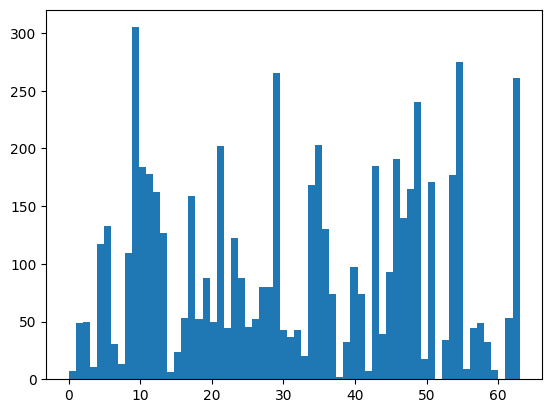

In [25]:
def target_circuit(init_para):  
    
    return sample_circ(init_para)


init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
s=time.time()
f_s_t=plt.hist(target_circuit(init_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')

0.060173749923706055 sec


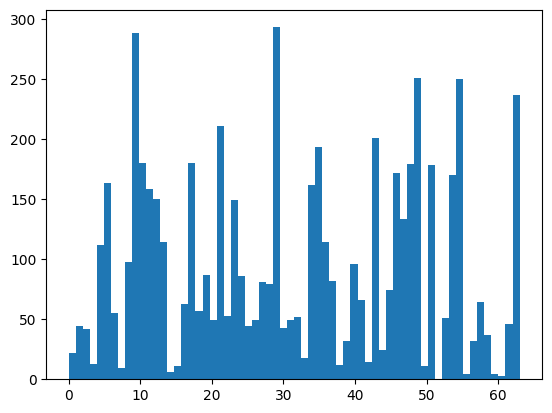

In [26]:
def target_circuit(init_para):  
    
    return sample_circ(init_para)


init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
s=time.time()
f_s_t=plt.hist(target_circuit(init_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [27]:
# pg=(f_s_t[0]/samples)

In [28]:
# np.savetxt('new_model_dist',pg)

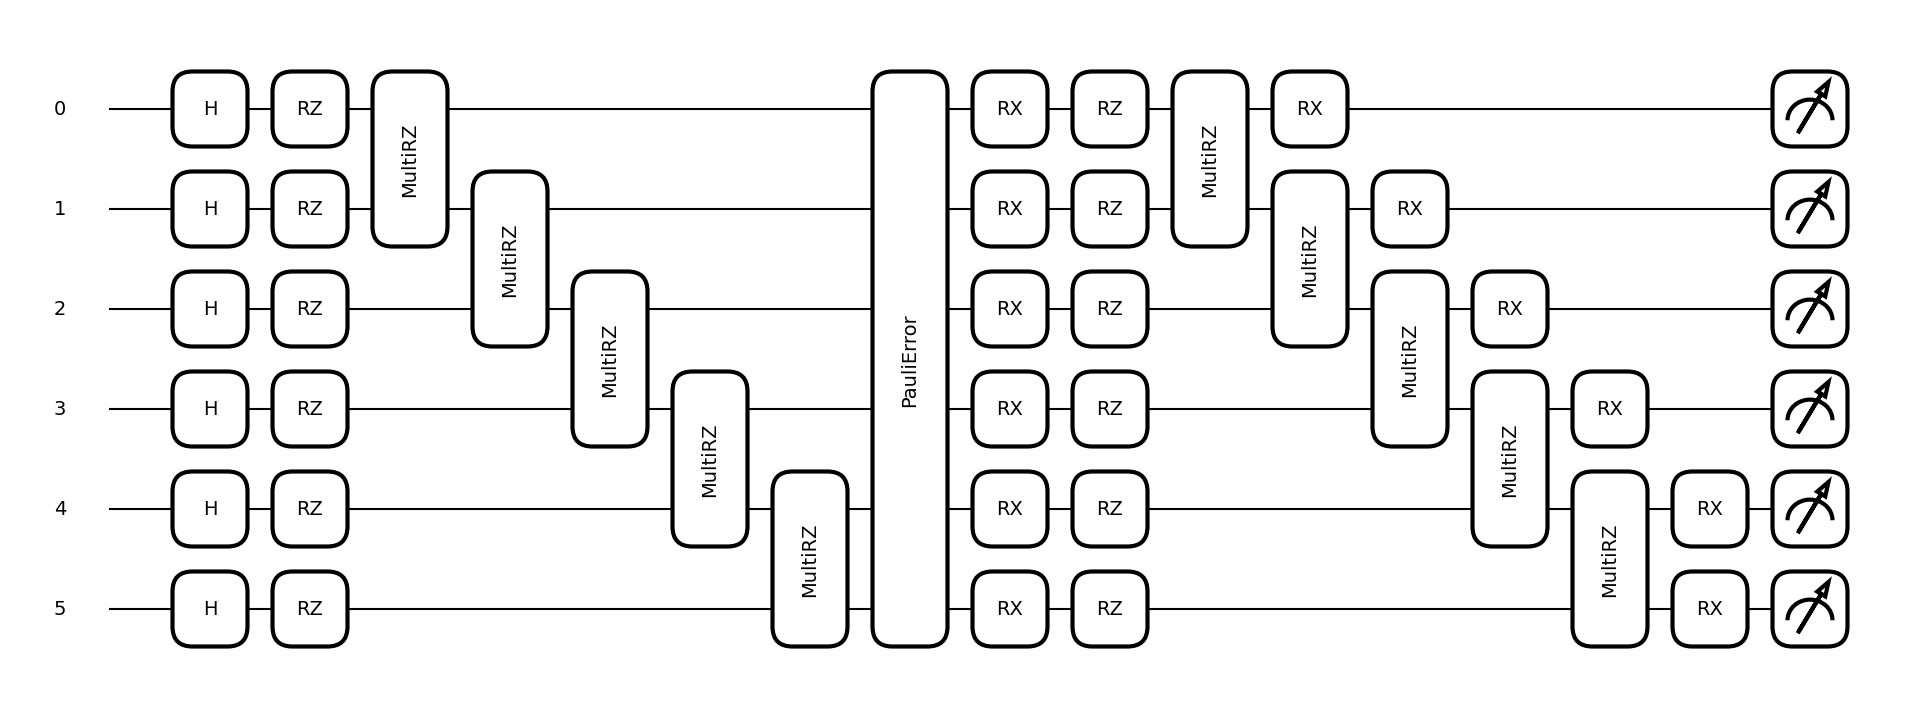

In [29]:
def plot_cqca_circuit(qubits=4):

    
    
    
    
    fig, ax = qml.draw_mpl(eqv_circ_st, expansion_strategy="device")(init_para)
    plt.show()

# Example:
plot_cqca_circuit(qubits=5)


In [30]:
pg = np.loadtxt('peaked_dist') #np.loadtxt('correlated_dist_test_2')
sum(pg)

tensor(1., requires_grad=True)

In [31]:
# sampling from target distribution e.g. mixed gaussian
def sample_target_function():
    x=range(2**qubits)
    ret = np.random.choice(x,samples,p=pg)
    return ret.copy()

0.06762838363647461 sec


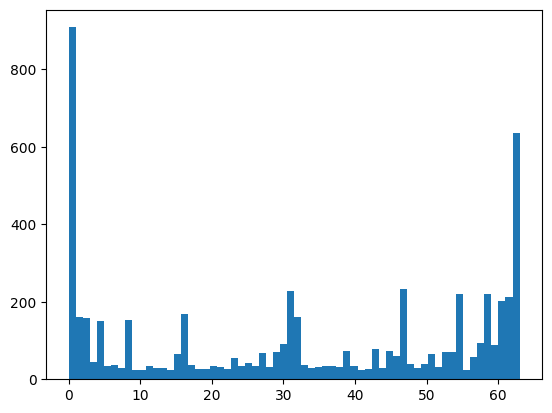

In [32]:
s=time.time()
opt_hist=plt.hist(sample_target_function(),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [33]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [34]:
# kernel function to calculate distance between two sample data points

def kernel_exp_torch(s1,s2):
    s1t = torch.tensor(s1, dtype = torch.float64).to(DEVICE)
    s2t = torch.tensor(s2, dtype = torch.float64).to(DEVICE)
    d1 = s1t.size(-1)
    d2 = s2t.size(-1)
    s1t = s1t.reshape([1,-1,1])
    s2t = s2t.reshape([1,-1,1])
    
    diffsquared = (torch.cdist(s1t,s2t,p=2.0).to(DEVICE))**2

    sigma_list=[4]
    exp = 0.0
    for sigma in sigma_list:
        expMatrix = torch.exp(diffsquared/(-2.0*sigma)).to(DEVICE)
        expMatrix = expMatrix/(len(sigma_list)*d1*d2)
        exp = exp + torch.sum(expMatrix).to(DEVICE)
        
    return exp

In [35]:
def mmd_loss(params):
    
    s2=sample_target_function()
    s1=sample_circ(params)
    res=kernel_exp_torch(s1,s1)-2*kernel_exp_torch(s1,s2)+kernel_exp_torch(s2,s2)
    return res.detach().cpu().numpy()


In [36]:
mmd_loss(init_para)

/home/arun/.local/lib/python3.10/site-packages/autoray/autoray.py:1127: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype, **kwargs)


array(0.07577338)

In [37]:
# Gradient for correction probabilities stated in eq. 17 of: https://arxiv.org/pdf/2310.13524.pdf

def mmd_grad_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    grad = torch.zeros(len(p)).to(DEVICE)
    
    
    
    sample_targ=sample_target_function()
    
    for i in range(len(p)):
        
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad[i]= grad[i]*inner_derivative
        p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])

        
    return grad


def mmd_grad_1layer_1p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    # grad = torch.zeros(len(p)).to(DEVICE)
    grad_1 = torch.zeros(len(p)).to(DEVICE)

    d=1 # The layer we want to train
    
    for i in range(1): # as you have only N prob that repeats across the first layer
            
        sample_targ=sample_target_function()
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad_1[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad_1[i]= grad_1[i]*inner_derivative
        p[i]=a
        
    # grad_1[:qubits]=grad_1[0] ## important step about where to put the byproducts

        
    return grad_1
    
    
# Gradient for variational parameters \thetas stated in eq. 16 of: https://arxiv.org/pdf/2310.13524.pdf
    
def mmd_grad_theta(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    prob = sample_circ(params)
    grad = torch.zeros(len(thetas)).to(DEVICE)
    
    for i in range(len(thetas)):
        # pi/2 phase
        thetas[i] += np.pi/2.
        prob_pos = sample_circ(params) # p_{theta}^{+}
        # -pi/2 phase
        thetas[i] -= np.pi
        prob_neg = sample_circ(params) # p_{theta}^{-}
        
        t1=kernel_exp_torch(prob, prob_pos)
        
        t2=kernel_exp_torch(prob, prob_neg)

        t3=kernel_exp_torch(sample_target_function(), prob_pos)
        
        t4=kernel_exp_torch(sample_target_function(), prob_neg)

        
        grad_pos = t1 - t2
        grad_neg = t3 - t4
        grad[i] = (grad_pos - grad_neg).detach().cpu()
        
        thetas[i] += np.pi/2.0 #reset to original value
        
    return grad


# combined gradient of both sets of parameters

def mmd_grad(params):
    #probs=params[:int(len(params)/2)]
    #thetas=params[len(probs):]
    grad=torch.cat((mmd_grad_1layer_1p_new(params),mmd_grad_theta(params)))
    return grad

In [38]:
'''
import torch
import gc
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
            print(obj.shape, type(obj), obj.size(), obj.device)
    except:
        pass
'''

"\nimport torch\nimport gc\nfor obj in gc.get_objects():\n    try:\n        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):\n            print(obj.shape, type(obj), obj.size(), obj.device)\n    except:\n        pass\n"

In [39]:
#torch.cuda.empty_cache()

In [40]:
#import gc

#gc.collect()
#torch.cuda.empty_cache()


In [41]:
# algorithm for gradient descent copied from : https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html

# We rewrote the algorithm with our approximate gradient calculated from samples instead of using the in-built exact gradient 

class GradientDescentOptimizer_mmd_2:  
    def __init__(self, stepsize): # if some value is given here itself then it will become a by default value
        self.stepsize = stepsize

    def step_and_cost(self, objective_fn, *args, grad_fn=None, **kwargs):
        
        g, forward = self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, args)

        if forward is None:
            forward = objective_fn(*args, **kwargs)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0], forward
        return new_args, forward


    def step(self, objective_fn, *args, train, grad_fn=None, **kwargs):
        
        p_len=int(len(args[0])/2)
        if train=='p':
            arg1=args[0][:int(len(args[0])/2)]
        else:
            arg1=args[0][int(len(args[0])/2):]
        
        g= self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, arg1,args,train)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0]

        return new_args

    @staticmethod
    def compute_grad(objective_fn, args, kwargs, grad_fn=None):
       
        
        grad = mmd_grad(*args).detach().cpu().numpy()
        

        num_trainable_args = sum(getattr(arg, "requires_grad", False) for arg in args)
        grad = (grad,) if num_trainable_args == 1 else grad
        #print('grads--',grad[0])
        return grad


    def apply_grad(self, grad, arg1,args,train):
        
        #print('arg1--',arg1)#################
        args_new = list(arg1)
        
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):

                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
        else:
            trained_index = p_len ########## need to be generalized
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
            
        
        #print('new args-->',args_new[0])#############
        
        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new]) # here we can do this only because the they have same size
        

In [42]:
# We use parts the above above algorithm to finally use the Adagrad optimization algorithm below to update our tunable parameters

from pennylane.numpy import sqrt
class AdagradOptimizer_mmd_2(GradientDescentOptimizer_mmd_2):
    

    def __init__(self, stepsize=0.01, eps=1e-8):
        super().__init__(stepsize)
        self.eps = eps
        self.accumulation = None

    def apply_grad(self, grad, arg1, args, train):
        
        p_len=int(len(args[0])/2)
        args_new = list(arg1)

        if self.accumulation is None:
            self.accumulation = [0.0] * len(arg1)
            
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
                    
        else:
            
            trained_index = p_len # need to be generalized
            
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
            
            

        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new])


    def _update_accumulation(self, index, grad):
        
        self.accumulation[index] = self.accumulation[index] + grad**2

    def reset(self):
        
        self.accumulation = None

In [43]:
def cost(par):

    c=mmd_loss(par) 
    return c

In [44]:
# cost(init_para)

In [ ]:
runs_2=20
iterations=299  # next time if run the same experiment for more agents then iterations=199


## seeding 
import random
import os

# Set seed for reproducibility (before any random ops)
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
####### end of seeding


# k=range(qubits)
cost_arr=[]
params_arr=[]
for r in range(runs_2):
    opt1 = AdagradOptimizer_mmd_2(stepsize=0.01)
    opt2 = AdagradOptimizer_mmd_2(stepsize=0.5)
    
   
    k=range(1)
    p2=np.ones(depth*(3*qubits-1))
    p2[k]=np.random.uniform(0.5,0.7,1)
    t2=np.random.uniform(0,1,depth*(3*qubits-1))
    init_p=np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
    params=init_p
    
    cost_arr.append(cost(init_p))
    params_arr.append(init_p)
    

    current_cost=[]
    
    for i in range(iterations):


        start=time.time()
        params = opt1.step(cost, params,train='p')
        params = opt2.step(cost, params,train='t')
        end=time.time()
        current_cost.append(cost(params))
        cost_arr.append(current_cost[i])
        

        params_arr.append(params)
        #params_arr_tot_2.append(params)

        if i % 1 == 0:
            print(f"Cost at step {i}:", current_cost[i],f'of run:{r}')

            
            print('time taken-->',(end-start)/60,'min')

    
    

Cost at step 0: 0.016343048824533163 of run:0
time taken--> 0.1238497813542684 min
Cost at step 1: 0.01850134867550647 of run:0
time taken--> 0.12431175311406453 min
Cost at step 2: 0.06617464382760777 of run:0
time taken--> 0.12442073424657187 min
Cost at step 3: 0.00749431365620945 of run:0
time taken--> 0.12447652022043863 min
Cost at step 4: 0.02427397261071476 of run:0
time taken--> 0.12450134754180908 min
Cost at step 5: 0.03468088873042821 of run:0
time taken--> 0.12454724709192912 min
Cost at step 6: 0.015706849137636633 of run:0
time taken--> 0.1243187149365743 min
Cost at step 7: 0.004699699802868509 of run:0
time taken--> 0.12465686003367106 min
Cost at step 8: 0.007115332377752498 of run:0
time taken--> 0.12500563859939576 min
Cost at step 9: 0.006686094236583784 of run:0
time taken--> 0.12454477548599244 min
Cost at step 10: 0.014440009107017274 of run:0
time taken--> 0.12682517369588217 min
Cost at step 11: 0.005828333356639556 of run:0
time taken--> 0.12463677326838175 m

In [607]:
sigmoid(params_arr[0][:])

tensor([0.13745401, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 0.95197226,
        0.90884613, 0.86769623, 0.62014106, 0.62012321, 0.5454926 ,
        0.93826449, 0.86857967, 0.902426  , 0.51616139, 0.9546555 ,
        0.93183317, 0.66084968, 0.63904463, 0.64018847, 0.72228115,
        0.83869782, 0.79527092, 0.71400657, 0.87238273, 0.60783788,
        0.71459352, 0.75968616, 0.80733505], requires_grad=True)

In [173]:
(params_arr[198][qubits*depth:]).reshape(depth, qubits).mean(axis=0)

tensor([0.52226159, 1.24945224, 0.40638021, 0.22387094, 0.41246383], requires_grad=True)

In [50]:
min(cost_arr)

array(0.0001227)

In [165]:
cost_arr.index(min(cost_arr))

240

In [166]:
opt_p=(params_arr[cost_arr.index(min(cost_arr))])

In [168]:
sigmoid(opt_p)

tensor([0.15653099, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 0.8387445 ,
        0.75071613, 0.85773041, 0.88194543, 0.53341727, 0.51563505,
        0.76832027, 0.63040245, 0.73098874, 0.71958516, 0.78531092,
        0.38596396, 0.7131333 , 0.7568387 , 0.40052032, 0.83254259,
        0.38527985, 0.75228485, 0.64224896, 0.79454489, 0.71829674,
        0.72420703, 0.76690667, 0.37825182], requires_grad=True)

In [548]:

mmd_loss(opt_p)

array(0.00082741)

In [ ]:
np.savetxt('models/class_1_peaked_loss_input_byp_model', cost_arr)

In [ ]:
np.savetxt('models/class_1_peaked_par_input_byp_model', params_arr)

In [85]:
ct = np.loadtxt('models/peaked_loss_end_channel_class_2')
(ct[253])

tensor(0.00053143, requires_grad=True)

In [108]:
pt = np.loadtxt('models/peaked_par_end_channel_class_2')
sigmoid(pt[253])

tensor([0.1366984 , 0.12783675, 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 0.97638714, 0.83370095, 0.61859984, 0.35603838,
        0.41930897, 0.65738268, 0.96208791, 0.69681758, 0.86343903,
        0.73529319, 0.97241535, 0.83578892, 0.24825715, 0.38163841,
        0.26406286, 0.77717502, 0.87502395, 0.79849806, 0.76461666,
        0.62629341, 0.59736282, 0.71935144, 0.7047864 , 0.86912982,
        0.8939476 , 0.79668178, 0.62050401, 0.96401458, 0.45431468,
        0.75688261, 0.27013997, 0.79294168, 0.91268953, 0.96698489,
        0.98088821, 0.65467329], requires_grad=T

In [220]:
def layerwise_hidden_statistics(probs):


    layer_mean_probs = np.mean(probs, axis=1)

    layer_std_probs = np.std(probs, axis=1)

    return (
        layer_mean_probs,
        layer_std_probs,
        probs
    )

In [223]:
# reshape trained parameters
probs = sigmoid(params_arr[cost_arr.index(min(cost_arr))][:qubits*depth])
probs = probs.reshape(depth, qubits)

(
    layer_means,
    layer_stds,
    probs
) = layerwise_hidden_statistics(probs)

print("Layer means:\n")
print(layer_means)

print("\nLayer stds:\n")
print(layer_stds)

print("\nAll hidden probabilities:\n")
print(probs)

Layer means:

[0.97522836 0.97309864 0.97242235 0.85970123]

Layer stds:

[0.00939532 0.00712165 0.00752522 0.22396454]

All hidden probabilities:

[[0.96945246 0.96066162 0.97579901 0.98501921 0.9852095 ]
 [0.96123445 0.97540628 0.98200337 0.96968298 0.97716611]
 [0.97145354 0.98353549 0.9626206  0.96665773 0.97784441]
 [0.97988826 0.970928   0.97289579 0.96289095 0.41190315]]


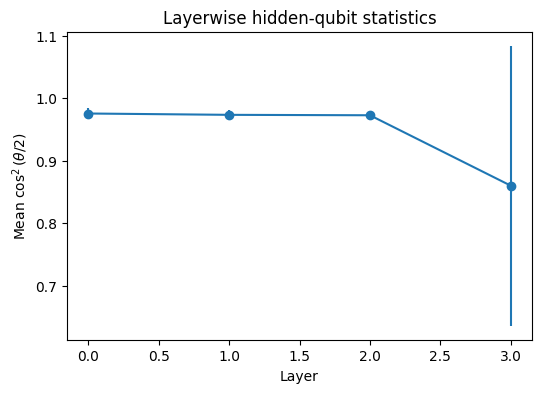

In [217]:
plt.figure(figsize=(6,4))

plt.errorbar(
    range(depth),
    layer_means,
    yerr=layer_stds,
    marker='o'
)

plt.xlabel("Layer")
plt.ylabel(r"Mean $\cos^2(\theta/2)$")

plt.title("Layerwise hidden-qubit statistics")

plt.show()